# Exercise 2: Exploratory Data Analysis (EDA)

## Analyse the PCL dataset using two distinct EDA techniques (3 marks each). For each technique, you must provide:
* Visual/Tabular Evidence: A figure or table.
* Analysis: A brief description of the findings.
* Impact Statement: An explanation of how this specific insight influences your approach to the PCL classification task.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from collections import Counter
import re

# Load datasets
train_df = pd.read_csv('../data/processed/train.csv')
dev_df = pd.read_csv('../data/processed/dev.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Convert label strings to lists (train and dev have labels, test does not)
train_df['label'] = train_df['label'].apply(ast.literal_eval)
dev_df['label'] = dev_df['label'].apply(ast.literal_eval)

print(f"Training set size: {len(train_df)}")
print(f"Development set size: {len(dev_df)}")
print(f"Test set size: {len(test_df)}")
print(f"\nNumber of labels per sample: {len(train_df['label'].iloc[0])}")

Training set size: 8375
Development set size: 2094
Test set size: 3832

Number of labels per sample: 7


## EDA Technique 1: Basic Statistical Profiling

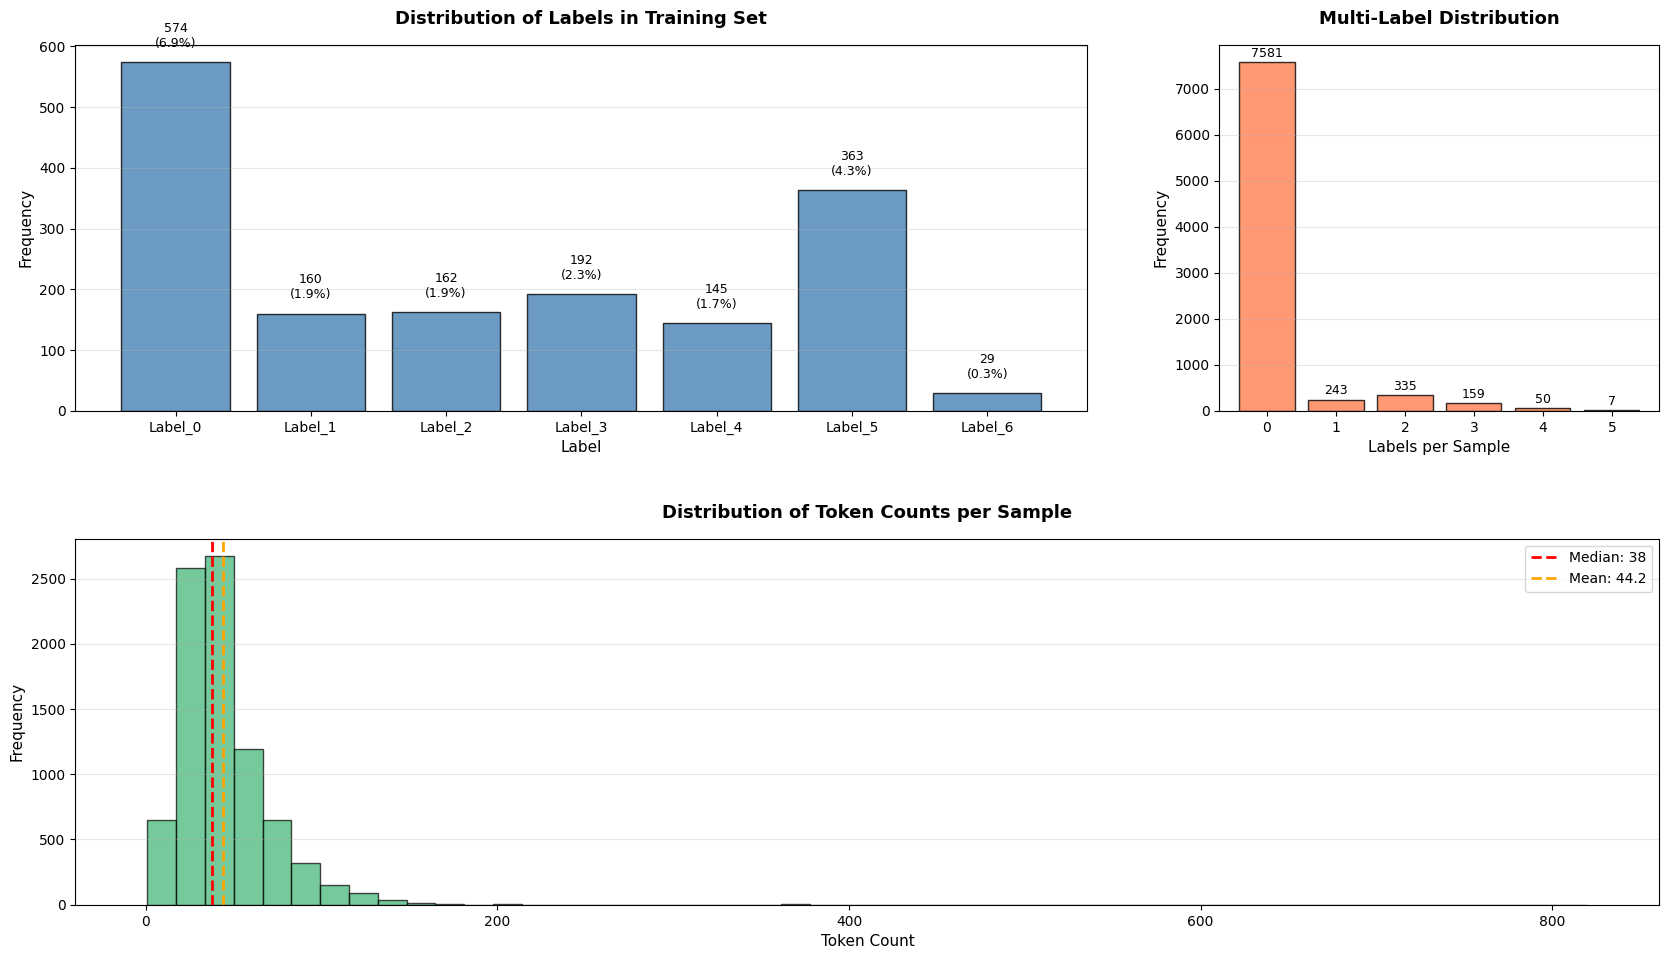

                    BASIC STATISTICAL PROFILING

[0] CLASS DISTRIBUTION (PCL vs Non-PCL)
----------------------------------------------------------------------
PCL samples:       794 (9.48%)
Non-PCL samples:  7581 (90.52%)
Total:            8375
Imbalance ratio: 1 : 9.5 (PCL : Non-PCL)

[1] LABEL DISTRIBUTION
----------------------------------------------------------------------
Label_0:   574 samples ( 6.85%)
Label_1:   160 samples ( 1.91%)
Label_2:   162 samples ( 1.93%)
Label_3:   192 samples ( 2.29%)
Label_4:   145 samples ( 1.73%)
Label_5:   363 samples ( 4.33%)
Label_6:    29 samples ( 0.35%)

[2] MULTI-LABEL STATISTICS
----------------------------------------------------------------------
Average labels per sample: 0.19
Min labels per sample: 0
Max labels per sample: 5
Samples with single label: 243 (2.9%)
Samples with multiple labels: 551 (6.6%)

[3] TOKEN COUNT STATISTICS
----------------------------------------------------------------------
Average token count: 44.18
Median t

In [2]:
# ============================================================================
# 1. LABEL DISTRIBUTION ANALYSIS
# ============================================================================

# Convert labels to array for analysis
labels_array = np.array(train_df['label'].tolist())
n_labels = labels_array.shape[1]

# Calculate label frequencies
label_names = [f'Label_{i}' for i in range(n_labels)]
label_counts = labels_array.sum(axis=0)
label_percentages = (label_counts / len(train_df)) * 100

# Calculate multi-label statistics
samples_per_label = labels_array.sum(axis=1)
unique, counts = np.unique(samples_per_label, return_counts=True)

# ============================================================================
# 2. TOKEN COUNT AND VOCABULARY SIZE
# ============================================================================

# Tokenize function
def tokenize(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b\w+\b", str(text).lower())

# Calculate token counts
train_df['tokens'] = train_df['text'].apply(tokenize)
train_df['token_count'] = train_df['tokens'].apply(len)

# Vocabulary size
vocab = Counter()
for tokens in train_df['tokens']:
    vocab.update(tokens)
vocab_size = len(vocab)

# Token count statistics
avg_tokens = train_df['token_count'].mean()
min_tokens = train_df['token_count'].min()
max_tokens = train_df['token_count'].max()
median_tokens = train_df['token_count'].median()

# ============================================================================
# 3. CREATE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3, top=0.94, bottom=0.08, left=0.08, right=0.96)

# Plot 1: Label distribution
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.bar(label_names, label_counts, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Label', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Labels in Training Set', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)
for i, (count, pct) in enumerate(zip(label_counts, label_percentages)):
    ax1.text(i, count + 20, f'{int(count)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Plot 2: Multi-label distribution
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(unique, counts, color='coral', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Labels per Sample', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Multi-Label Distribution', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)
for x, y in zip(unique, counts):
    ax2.text(x, y + 50, f'{int(y)}', ha='center', va='bottom', fontsize=9)

# Plot 3: Token count distribution
ax3 = fig.add_subplot(gs[1, :])
ax3.hist(train_df['token_count'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
ax3.axvline(median_tokens, color='red', linestyle='--', linewidth=2, label=f'Median: {median_tokens:.0f}')
ax3.axvline(avg_tokens, color='orange', linestyle='--', linewidth=2, label=f'Mean: {avg_tokens:.1f}')
ax3.set_xlabel('Token Count', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of Token Counts per Sample', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

plt.savefig('../report/figures/basic_statistical_profiling.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. PRINT SUMMARY STATISTICS
# ============================================================================

print("=" * 70)
print(" " * 20 + "BASIC STATISTICAL PROFILING")
print("=" * 70)

print("\n[0] CLASS DISTRIBUTION (PCL vs Non-PCL)")
print("-" * 70)
n_pcl = int((samples_per_label > 0).sum())
n_non_pcl = int((samples_per_label == 0).sum())
total = len(train_df)
print(f"PCL samples:     {n_pcl:5d} ({n_pcl/total*100:.2f}%)")
print(f"Non-PCL samples: {n_non_pcl:5d} ({n_non_pcl/total*100:.2f}%)")
print(f"Total:           {total:5d}")
print(f"Imbalance ratio: 1 : {n_non_pcl/n_pcl:.1f} (PCL : Non-PCL)")

print("\n[1] LABEL DISTRIBUTION")
print("-" * 70)
for i, (name, count, pct) in enumerate(zip(label_names, label_counts, label_percentages)):
    print(f"{name}: {int(count):5d} samples ({pct:5.2f}%)")

print("\n[2] MULTI-LABEL STATISTICS")
print("-" * 70)
print(f"Average labels per sample: {samples_per_label.mean():.2f}")
print(f"Min labels per sample: {int(samples_per_label.min())}")
print(f"Max labels per sample: {int(samples_per_label.max())}")
print(f"Samples with single label: {(samples_per_label == 1).sum()} ({(samples_per_label == 1).sum()/len(train_df)*100:.1f}%)")
print(f"Samples with multiple labels: {(samples_per_label > 1).sum()} ({(samples_per_label > 1).sum()/len(train_df)*100:.1f}%)")

print("\n[3] TOKEN COUNT STATISTICS")
print("-" * 70)
print(f"Average token count: {avg_tokens:.2f}")
print(f"Median token count: {median_tokens:.0f}")
print(f"Minimum token count: {min_tokens}")
print(f"Maximum token count: {max_tokens}")
print(f"Standard deviation: {train_df['token_count'].std():.2f}")

print("\n[4] VOCABULARY SIZE")
print("-" * 70)
print(f"Unique tokens (vocabulary size): {vocab_size:,}")
print(f"This determines the embedding layer size for the model.")

print("\n" + "=" * 70)

## EDA Technique 2: Lexical Analysis (The "Word" Level)

PCL samples: 794
Non-PCL samples: 7581
N-gram extraction complete

Trigram per-sample rates (PCL vs Non-PCL):
Trigram                   PCL cnt   PCL % Non-PCL cnt  Non-PCL %   Ratio
----------------------------------------------------------------------
in need of                     42   5.29%         422      5.57%    1.0x
those in need                  40   5.04%          88      1.16%    4.3x
from poor families             27   3.40%         150      1.98%    1.7x
do n t                         18   2.27%         151      1.99%    1.1x
to those in                    18   2.27%          27      0.36%    6.4x
people in need                 16   2.02%          53      0.70%    2.9x
ca n t                         15   1.89%          61      0.80%    2.3x
children from poor             14   1.76%          35      0.46%    3.8x

Stop-word density — PCL: mean=48.47%  median=48.78%  std=9.72%
Stop-word density — Non-PCL: mean=45.01%  median=45.16%  std=9.46%
Difference: 3.46 pp
Word freque

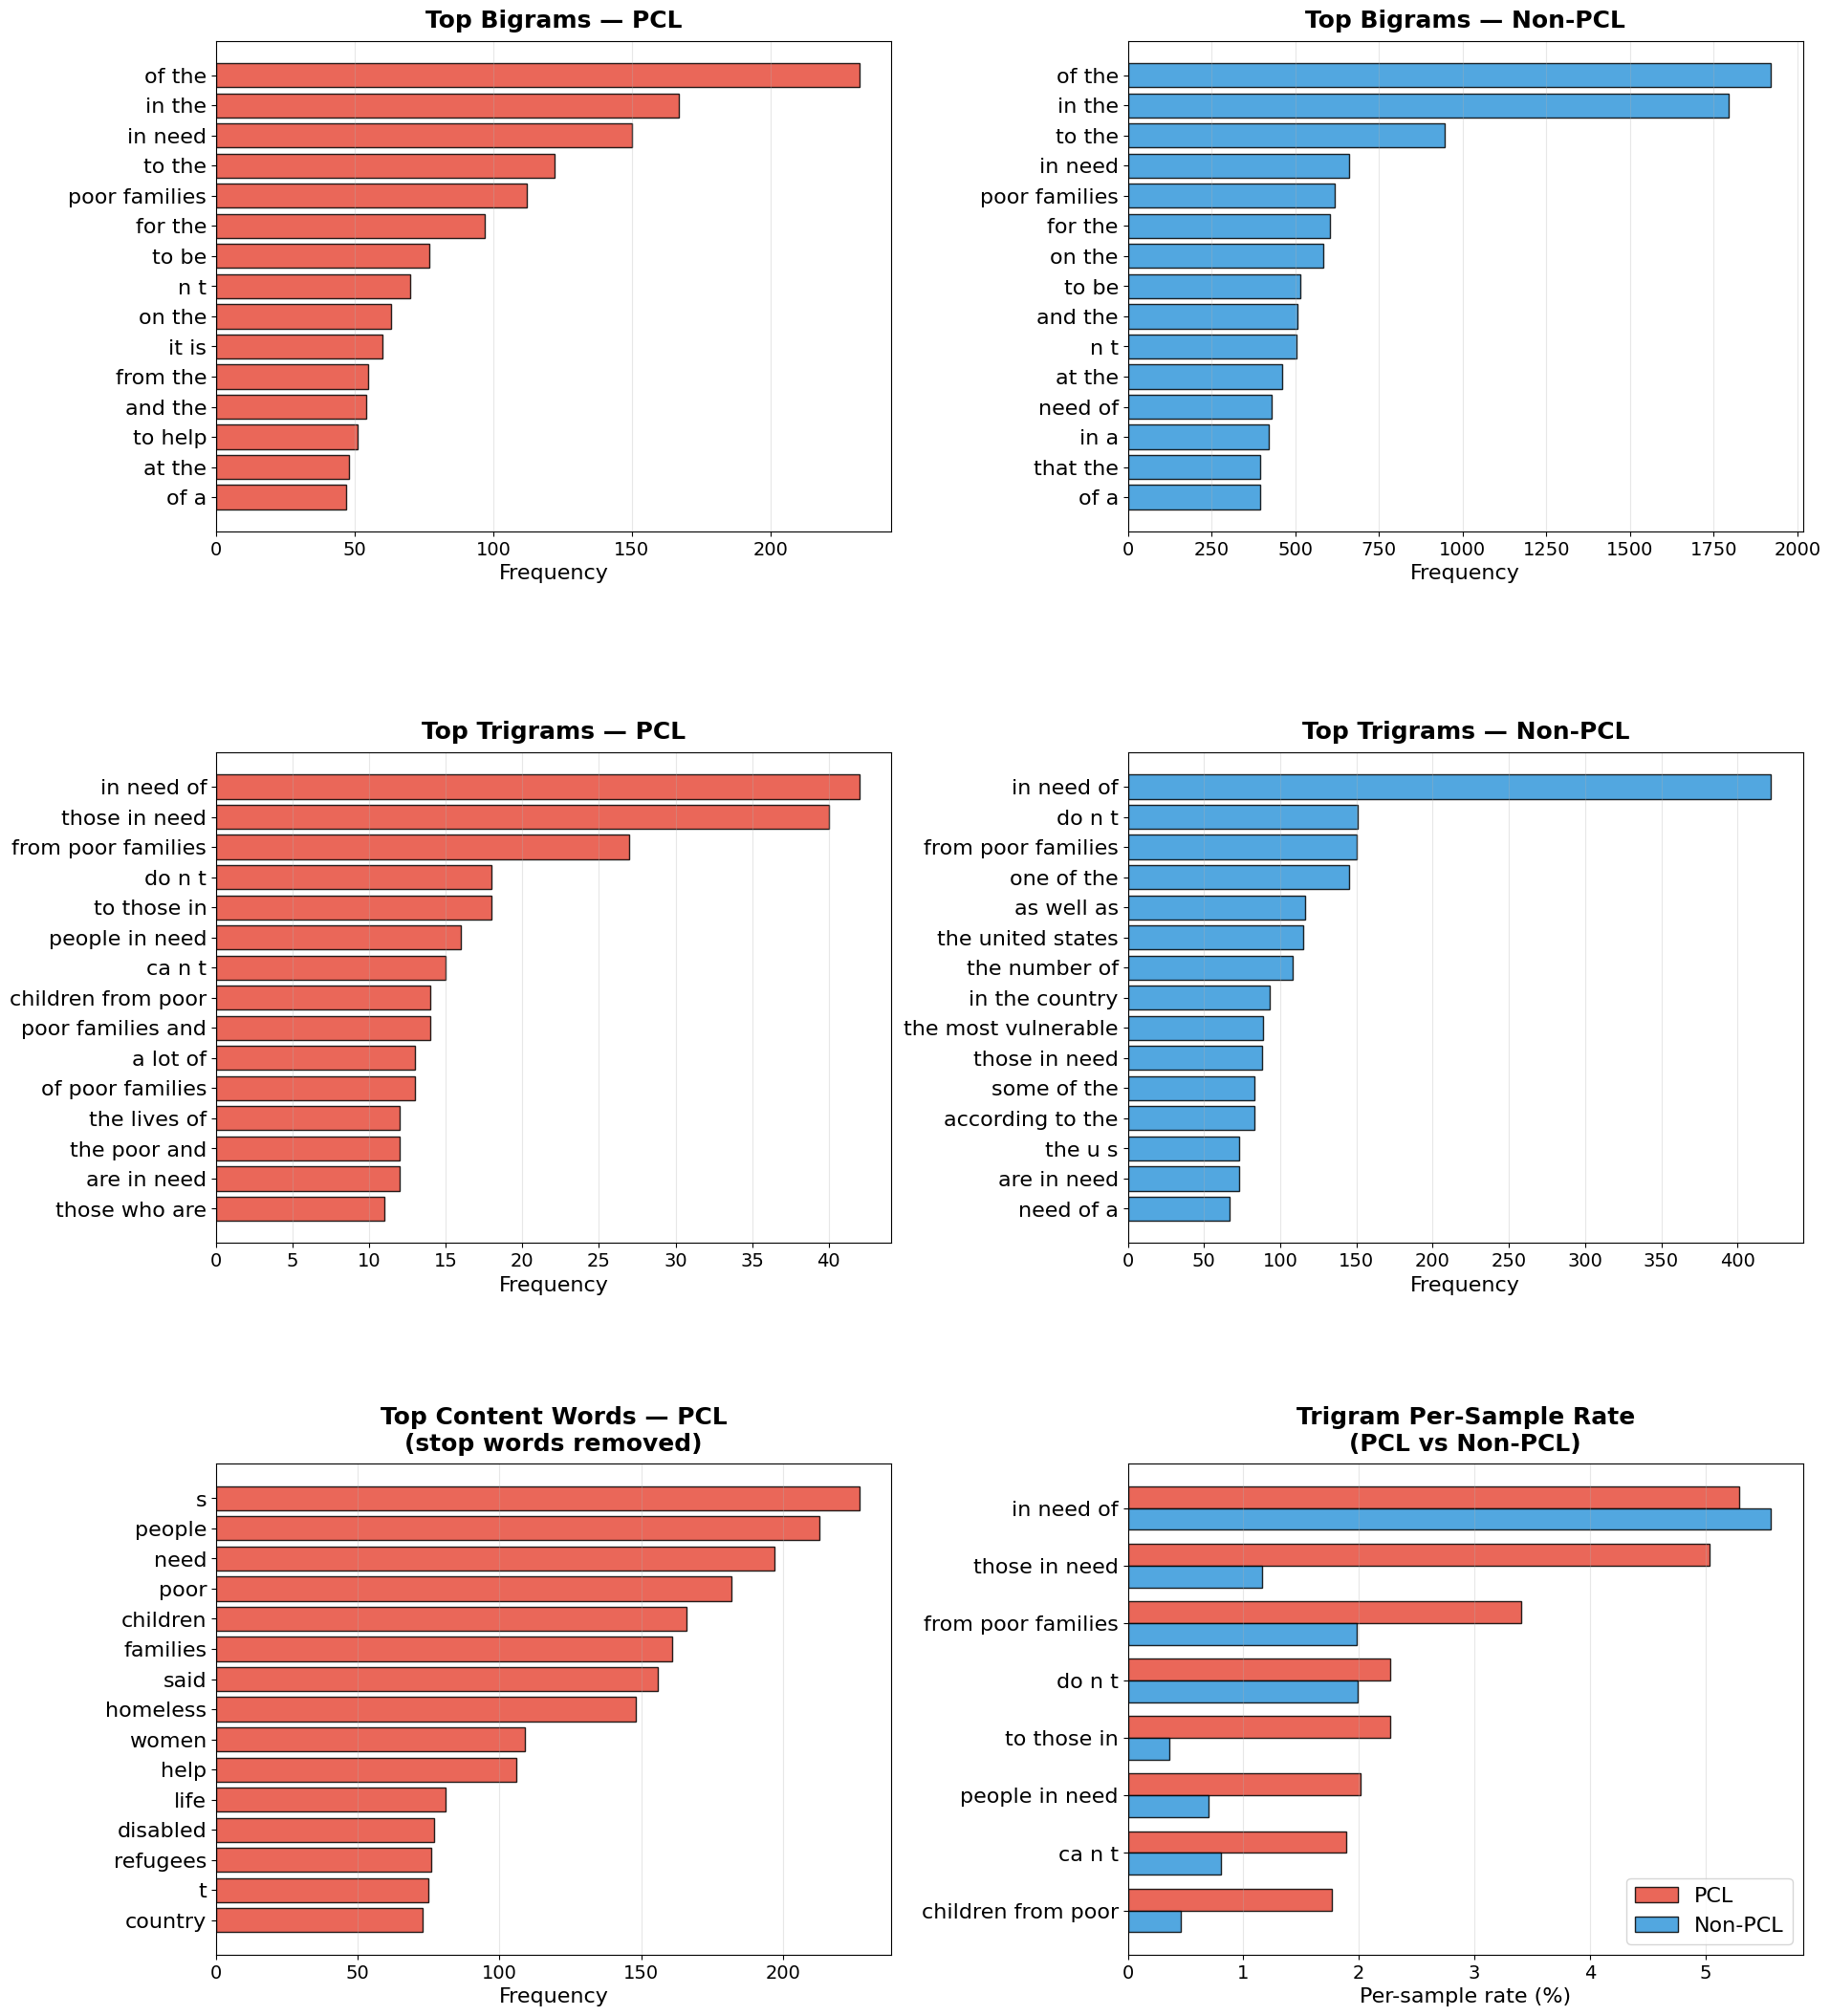

Saved lexical_analysis_ngrams.png


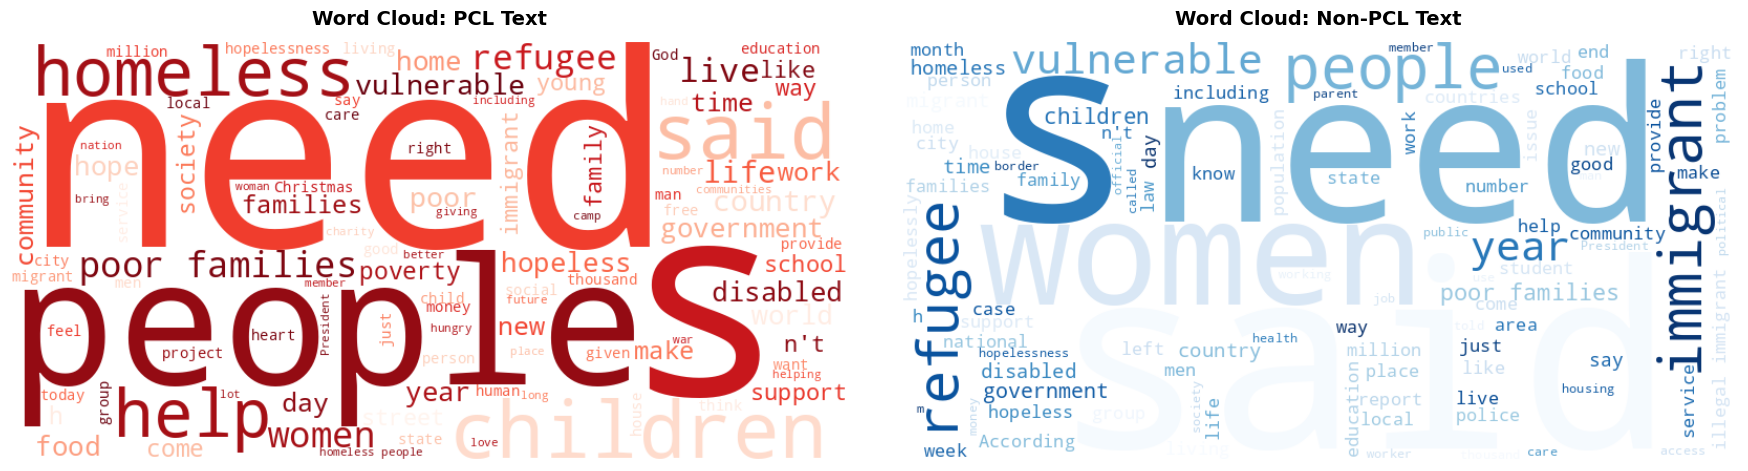

Saved lexical_analysis_wordclouds.png

                         LEXICAL ANALYSIS RESULTS

[1] TOP BIGRAMS
--------------------------------------------------------------------------------
PCL Bigram                       Freq       %   ||  Non-PCL Bigram                   Freq       %
--------------------------------------------------------------------------------
of the                            232  29.22%   ||  of the                           1921  25.34%
in the                            167  21.03%   ||  in the                           1795  23.68%
in need                           150  18.89%   ||  to the                            947  12.49%
to the                            122  15.37%   ||  in need                           661   8.72%
poor families                     112  14.11%   ||  poor families                     617   8.14%
for the                            97  12.22%   ||  for the                           605   7.98%
to be                              77   9.70% 

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PREPARE DATA: Separate PCL vs Non-PCL texts
# ============================================================================

train_df['is_pcl'] = train_df['label'].apply(lambda x: 1 if sum(x) > 0 else 0)

pcl_texts = train_df[train_df['is_pcl'] == 1]['text'].tolist()
non_pcl_texts = train_df[train_df['is_pcl'] == 0]['text'].tolist()

n_pcl_samples = len(pcl_texts)
n_non_pcl_samples = len(non_pcl_texts)
print(f"PCL samples: {n_pcl_samples}")
print(f"Non-PCL samples: {n_non_pcl_samples}")

# ============================================================================
# 1. N-GRAM ANALYSIS (Bigrams and Trigrams)
# ============================================================================

def extract_ngrams(texts, n=2, top_k=15):
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        max_features=None,
        stop_words=None,
        lowercase=True,
        token_pattern=r'\b\w+\b'
    )
    ngram_matrix = vectorizer.fit_transform(texts)
    ngram_counts = np.array(ngram_matrix.sum(axis=0)).flatten()
    ngrams = vectorizer.get_feature_names_out()
    top_indices = ngram_counts.argsort()[-top_k:][::-1]
    return [(ngrams[i], ngram_counts[i]) for i in top_indices]

pcl_bigrams    = extract_ngrams(pcl_texts,     n=2, top_k=15)
non_pcl_bigrams = extract_ngrams(non_pcl_texts, n=2, top_k=15)
pcl_trigrams    = extract_ngrams(pcl_texts,     n=3, top_k=15)
non_pcl_trigrams = extract_ngrams(non_pcl_texts, n=3, top_k=15)
print("N-gram extraction complete")

# ============================================================================
# 2. PER-SAMPLE ENRICHMENT RATES FOR KEY TRIGRAMS
# ============================================================================

def get_ngram_rates(texts, target_ngrams, n=3):
    """Return (raw_counts, per-sample %) for each target ngram in texts."""
    vocab = {ng: i for i, ng in enumerate(target_ngrams)}
    vec = CountVectorizer(
        ngram_range=(n, n), vocabulary=vocab,
        lowercase=True, token_pattern=r'\b\w+\b'
    )
    mat = vec.fit_transform(texts)
    counts = np.array(mat.sum(axis=0)).flatten()
    return counts, counts / len(texts) * 100

# Use top-8 PCL trigrams as the reference set
top_pcl_tri_names = [tg for tg, _ in pcl_trigrams[:8]]

pcl_tri_counts,     pcl_tri_rates     = get_ngram_rates(pcl_texts,     top_pcl_tri_names)
non_pcl_tri_counts, non_pcl_tri_rates = get_ngram_rates(non_pcl_texts, top_pcl_tri_names)
enrichment_ratios = pcl_tri_rates / np.where(non_pcl_tri_rates == 0, 1e-6, non_pcl_tri_rates)

print("\nTrigram per-sample rates (PCL vs Non-PCL):")
print(f"{'Trigram':<25} {'PCL cnt':>7} {'PCL %':>7} {'Non-PCL cnt':>11} {'Non-PCL %':>10} {'Ratio':>7}")
print("-" * 70)
for name, pc, pr, nc, nr, ratio in zip(
        top_pcl_tri_names, pcl_tri_counts, pcl_tri_rates,
        non_pcl_tri_counts, non_pcl_tri_rates, enrichment_ratios):
    print(f"{name:<25} {int(pc):>7} {pr:>6.2f}% {int(nc):>11} {nr:>9.2f}% {ratio:>6.1f}x")

# ============================================================================
# 3. STOP WORD DENSITY (computed for reference, no longer plotted)
# ============================================================================

def calculate_stop_word_density(texts):
    densities = []
    stop_words = set(ENGLISH_STOP_WORDS)
    for text in texts:
        if pd.isna(text): continue
        tokens = re.findall(r'\b\w+\b', str(text).lower())
        if not tokens: continue
        densities.append(sum(1 for t in tokens if t in stop_words) / len(tokens) * 100)
    return densities

pcl_stop_densities     = calculate_stop_word_density(pcl_texts)
non_pcl_stop_densities = calculate_stop_word_density(non_pcl_texts)

print(f"\nStop-word density — PCL: mean={np.mean(pcl_stop_densities):.2f}%  "
      f"median={np.median(pcl_stop_densities):.2f}%  std={np.std(pcl_stop_densities):.2f}%")
print(f"Stop-word density — Non-PCL: mean={np.mean(non_pcl_stop_densities):.2f}%  "
      f"median={np.median(non_pcl_stop_densities):.2f}%  std={np.std(non_pcl_stop_densities):.2f}%")
print(f"Difference: {np.mean(pcl_stop_densities) - np.mean(non_pcl_stop_densities):.2f} pp")

# ============================================================================
# 4. WORD FREQUENCY
# ============================================================================

def get_word_frequencies(texts, top_k=20):
    vectorizer = CountVectorizer(max_features=top_k, stop_words='english',
                                 lowercase=True, token_pattern=r'\b\w+\b')
    mat = vectorizer.fit_transform(texts)
    counts = np.array(mat.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()
    freqs = [(words[i], counts[i]) for i in range(len(words))]
    freqs.sort(key=lambda x: x[1], reverse=True)
    return freqs

pcl_word_freqs     = get_word_frequencies(pcl_texts,     top_k=20)
non_pcl_word_freqs = get_word_frequencies(non_pcl_texts, top_k=20)
print("Word frequency analysis complete")

# ============================================================================
# 5. FIGURE A — N-gram analysis (3×2 grid)
# ============================================================================

LABEL_FS  = 16   # y-tick label font size (the ngram text)
TITLE_FS  = 18   # subplot title font size
AXIS_FS   = 16   # axis label font size
LEGEND_FS = 16   # legend font size

fig_a, axes_a = plt.subplots(3, 2, figsize=(20, 22))
fig_a.subplots_adjust(hspace=0.45, wspace=0.35, top=0.95, bottom=0.04, left=0.14, right=0.97)

def plot_hbar(ax, items, color, title):
    words  = [it[0] for it in items]
    counts = [it[1] for it in items]
    y = np.arange(len(words))
    ax.barh(y, counts, color=color, alpha=0.85, edgecolor='black')
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=LABEL_FS)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=AXIS_FS)
    ax.set_title(title, fontsize=TITLE_FS, fontweight='bold', pad=10)
    ax.tick_params(axis='x', labelsize=14)
    ax.grid(axis='x', alpha=0.3)

# Row 1: Bigrams
plot_hbar(axes_a[0, 0], pcl_bigrams,     '#E74C3C', 'Top Bigrams — PCL')
plot_hbar(axes_a[0, 1], non_pcl_bigrams, '#3498DB', 'Top Bigrams — Non-PCL')

# Row 2: Trigrams
plot_hbar(axes_a[1, 0], pcl_trigrams,     '#E74C3C', 'Top Trigrams — PCL')
plot_hbar(axes_a[1, 1], non_pcl_trigrams, '#3498DB', 'Top Trigrams — Non-PCL')

# Row 3, Col 1: Top content words (PCL)
plot_hbar(axes_a[2, 0], pcl_word_freqs[:15], '#E74C3C',
          'Top Content Words — PCL\n(stop words removed)')

# Row 3, Col 2: Trigram per-sample enrichment (grouped bar)
ax_enrich = axes_a[2, 1]
bar_w = 0.38
y_pos = np.arange(len(top_pcl_tri_names))
ax_enrich.barh(y_pos - bar_w/2, pcl_tri_rates,     bar_w, label='PCL',     color='#E74C3C', alpha=0.85, edgecolor='black')
ax_enrich.barh(y_pos + bar_w/2, non_pcl_tri_rates, bar_w, label='Non-PCL', color='#3498DB', alpha=0.85, edgecolor='black')
ax_enrich.set_yticks(y_pos)
ax_enrich.set_yticklabels(top_pcl_tri_names, fontsize=LABEL_FS)
ax_enrich.invert_yaxis()
ax_enrich.set_xlabel('Per-sample rate (%)', fontsize=AXIS_FS)
ax_enrich.set_title('Trigram Per-Sample Rate\n(PCL vs Non-PCL)', fontsize=TITLE_FS, fontweight='bold', pad=10)
ax_enrich.tick_params(axis='x', labelsize=14)
ax_enrich.legend(fontsize=LEGEND_FS, loc='lower right')
ax_enrich.grid(axis='x', alpha=0.3)

fig_a.savefig('../report/figures/lexical_analysis_ngrams.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved lexical_analysis_ngrams.png")

# ============================================================================
# 6. FIGURE B — Word clouds (1×2, equal sizes)
# ============================================================================

fig_b, (ax_wc1, ax_wc2) = plt.subplots(1, 2, figsize=(18, 5))
fig_b.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02, wspace=0.06)

wc_pcl = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100, relative_scaling=0.5,
                   stopwords=ENGLISH_STOP_WORDS).generate(' '.join(pcl_texts))
ax_wc1.imshow(wc_pcl, interpolation='bilinear')
ax_wc1.axis('off')
ax_wc1.set_title('Word Cloud: PCL Text', fontsize=14, fontweight='bold', pad=12)

wc_non = WordCloud(width=800, height=400, background_color='white',
                   colormap='Blues', max_words=100, relative_scaling=0.5,
                   stopwords=ENGLISH_STOP_WORDS).generate(' '.join(non_pcl_texts))
ax_wc2.imshow(wc_non, interpolation='bilinear')
ax_wc2.axis('off')
ax_wc2.set_title('Word Cloud: Non-PCL Text', fontsize=14, fontweight='bold', pad=12)

fig_b.savefig('../report/figures/lexical_analysis_wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved lexical_analysis_wordclouds.png")

# ============================================================================
# 7. PRINT DETAILED STATS
# ============================================================================

print("\n" + "=" * 80)
print(" " * 25 + "LEXICAL ANALYSIS RESULTS")
print("=" * 80)

print("\n[1] TOP BIGRAMS")
print("-" * 80)
print(f"{'PCL Bigram':<30} {'Freq':>6}  {'%':>6}   ||  {'Non-PCL Bigram':<30} {'Freq':>6}  {'%':>6}")
print("-" * 80)
for (bg, bc), (nbg, nbc) in zip(pcl_bigrams[:10], non_pcl_bigrams[:10]):
    print(f"{bg:<30} {int(bc):>6}  {bc/n_pcl_samples*100:>5.2f}%   ||  {nbg:<30} {int(nbc):>6}  {nbc/n_non_pcl_samples*100:>5.2f}%")

print("\n[2] TOP TRIGRAMS (with per-sample %)")
print("-" * 80)
print(f"{'PCL Trigram':<30} {'Freq':>6}  {'%':>6}   ||  {'Non-PCL Trigram':<30} {'Freq':>6}  {'%':>6}")
print("-" * 80)
for (tg, tc), (ntg, ntc) in zip(pcl_trigrams[:10], non_pcl_trigrams[:10]):
    print(f"{tg:<30} {int(tc):>6}  {tc/n_pcl_samples*100:>5.2f}%   ||  {ntg:<30} {int(ntc):>6}  {ntc/n_non_pcl_samples*100:>5.2f}%")

print("\n[3] ENRICHMENT TABLE (top PCL trigrams in both classes)")
print("-" * 80)
print(f"{'Trigram':<25} {'PCL cnt':>7} {'PCL %':>7} {'Non-PCL cnt':>11} {'Non-PCL %':>10} {'Ratio':>7}")
print("-" * 80)
for name, pc, pr, nc, nr, ratio in zip(
        top_pcl_tri_names, pcl_tri_counts, pcl_tri_rates,
        non_pcl_tri_counts, non_pcl_tri_rates, enrichment_ratios):
    print(f"{name:<25} {int(pc):>7} {pr:>6.2f}% {int(nc):>11} {nr:>9.2f}% {ratio:>6.1f}x")

print("\n[4] STOP WORD DENSITY (reference only)")
print("-" * 80)
print(f"PCL:     mean={np.mean(pcl_stop_densities):.2f}%  median={np.median(pcl_stop_densities):.2f}%  std={np.std(pcl_stop_densities):.2f}%")
print(f"Non-PCL: mean={np.mean(non_pcl_stop_densities):.2f}%  median={np.median(non_pcl_stop_densities):.2f}%  std={np.std(non_pcl_stop_densities):.2f}%")

print("\n[5] DISTINCTIVE WORDS (stop words removed)")
print("-" * 80)
print(f"\nMost frequent in PCL:")
for rank, (word, count) in enumerate(pcl_word_freqs[:10], 1):
    print(f"  {rank:2d}. '{word}' — {int(count):,} ({count/n_pcl_samples*100:.1f}%)")
print(f"\nMost frequent in Non-PCL:")
for rank, (word, count) in enumerate(non_pcl_word_freqs[:10], 1):
    print(f"  {rank:2d}. '{word}' — {int(count):,} ({count/n_non_pcl_samples*100:.1f}%)")

print("\n" + "=" * 80)
